### 课程一（15%）

##### 1.环境配置

编译器安装:Visual Studio Code/Pycharm

Python环境管理:Python虚拟环境搭建(conda/venv),推荐安装anaconda/miniconda进行环境管理

https://blog.csdn.net/ming12131342/article/details/140233867

验证安装，终端运行 `conda --version`

换源：[ubuntu、conda、pip 换北外源（北京外国语大学开源软件镜像站）_北外临时源-CSDN博客](https://blog.csdn.net/weixin_43667077/article/details/108282523)

创建虚拟环境

`conda create -n speech_env python=3.8 `

`conda activate speech_env`

##### 2.安装numpy,matplotlib,librosa,pandas

In [23]:
# 环境已由 conda(speechcore) 预装，无需再装
# %pip install numpy matplotlib librosa pandas

##### 3.导入librosa,pandas,numpy,matplotlib,IPython

In [24]:
import librosa  
import matplotlib.pyplot as plt  
import IPython.display as ipd
import pandas as pd
import numpy as np

##### 4.使用IPython展示音频

In [25]:
audio_file = 'LJ001-0011.wav'
ipd.Audio(audio_file)

##### 5.使用librosa加载音频,打印加载的音频shape,音频采样率

In [26]:
y, sr = librosa.load(audio_file)
print(type(y))
print(f'shape y: {y.shape}')
print(f'sr: {sr}')

<class 'numpy.ndarray'>
shape y: (99485,)
sr: 22050


##### 6.使用matplotlib包绘制音频

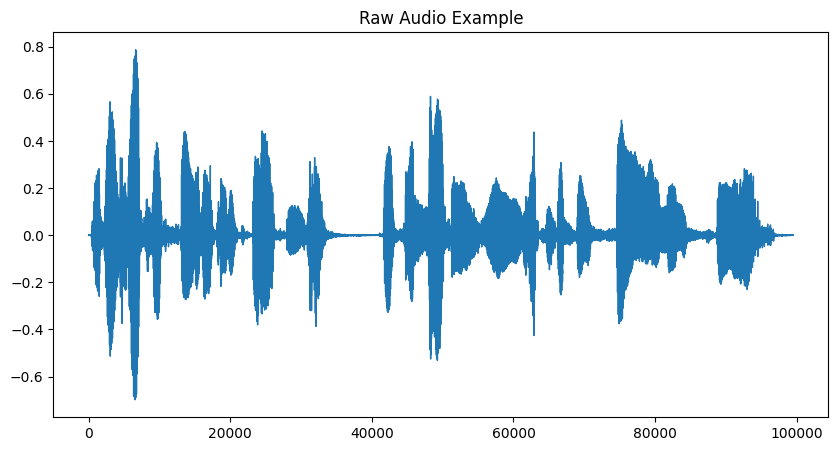

In [27]:
#序列化音频数据
pd.Series(y).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

##### 7.使用librosa计算音频的幅度谱图,打印幅度谱shape并使用matplotlib进行绘制

(1025, 195)


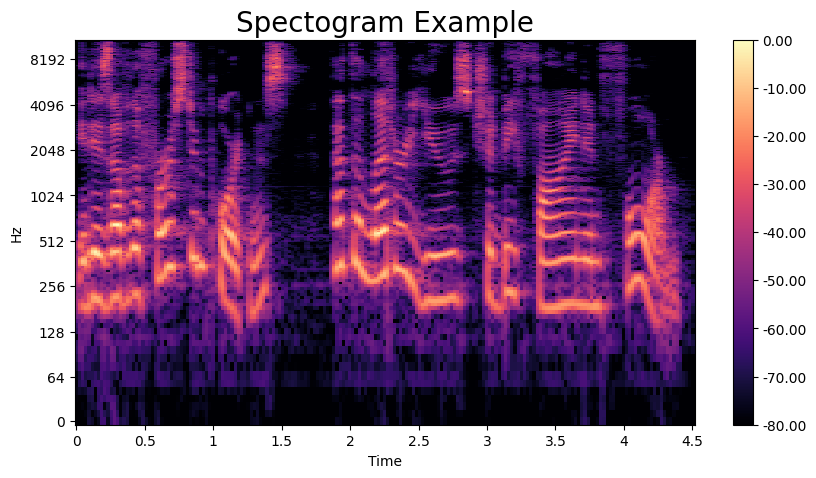

In [28]:
#把加载的音频通过短时傅里叶变换
D = librosa.stft(y)
#取复数矩阵的模,得到幅度
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
print(S_db.shape)

# Plot the transformed audio data
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

##### 8.使用librosa计算并绘制mel谱

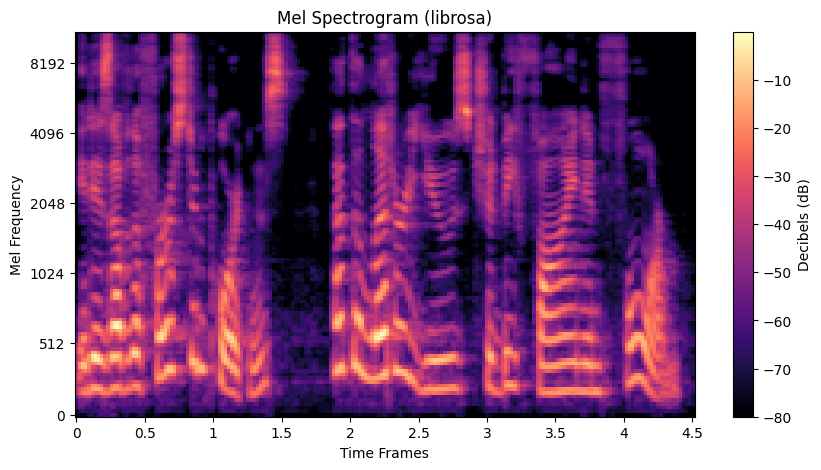

In [29]:
n_fft = 2048       # FFT 大小
hop_length = 512   # 帧移
n_mels = 128       # Mel 频带数
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 5))
librosa.display.specshow(mel_spec_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel")
plt.colorbar(label="Decibels (dB)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency")
plt.title("Mel Spectrogram (librosa)")
plt.show()

##### 9.安装torch,torchaudio
https://pytorch.org/

GPU环境搭建：

https://blog.csdn.net/2501_91798322/article/details/154492010

In [30]:
# 环境已由 conda(speechcore) 预装 
# %pip install torch torchaudio

In [31]:
import torch, torchaudio
print(torch.__version__)
print(torch.cuda.is_available()) 

2.1.2+cu118
True


##### 10.使用torchaudio加载音频,计算mel谱并绘制

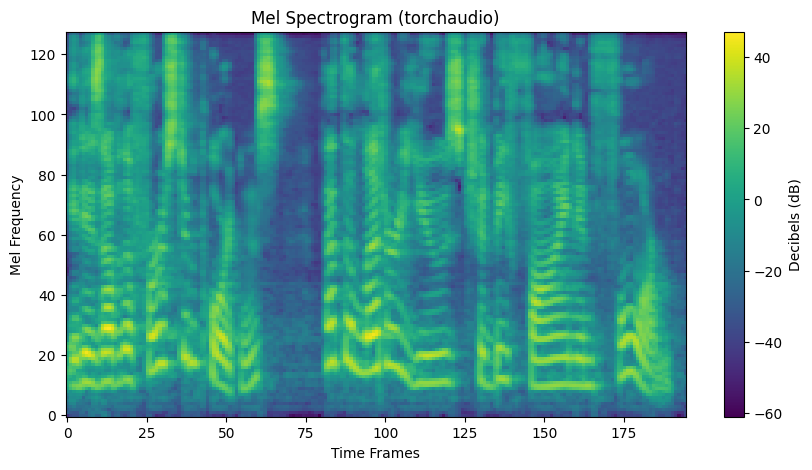

In [32]:
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
waveform, sample_rate = torchaudio.load("LJ001-0011.wav")

n_fft = 2048
n_mels = 128
hop_length = 512

# TODO：调用函数计算 Mel 频谱图
mel_transform = T.MelSpectrogram(sample_rate=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mel_spec = mel_transform(waveform)
mel_spec_db = T.AmplitudeToDB(stype="power")(mel_spec)

plt.figure(figsize=(10, 5))
plt.imshow(mel_spec_db[0].numpy(), aspect="auto", origin="lower")
plt.colorbar(label="Decibels (dB)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency")
plt.title("Mel Spectrogram (torchaudio)")
plt.show()

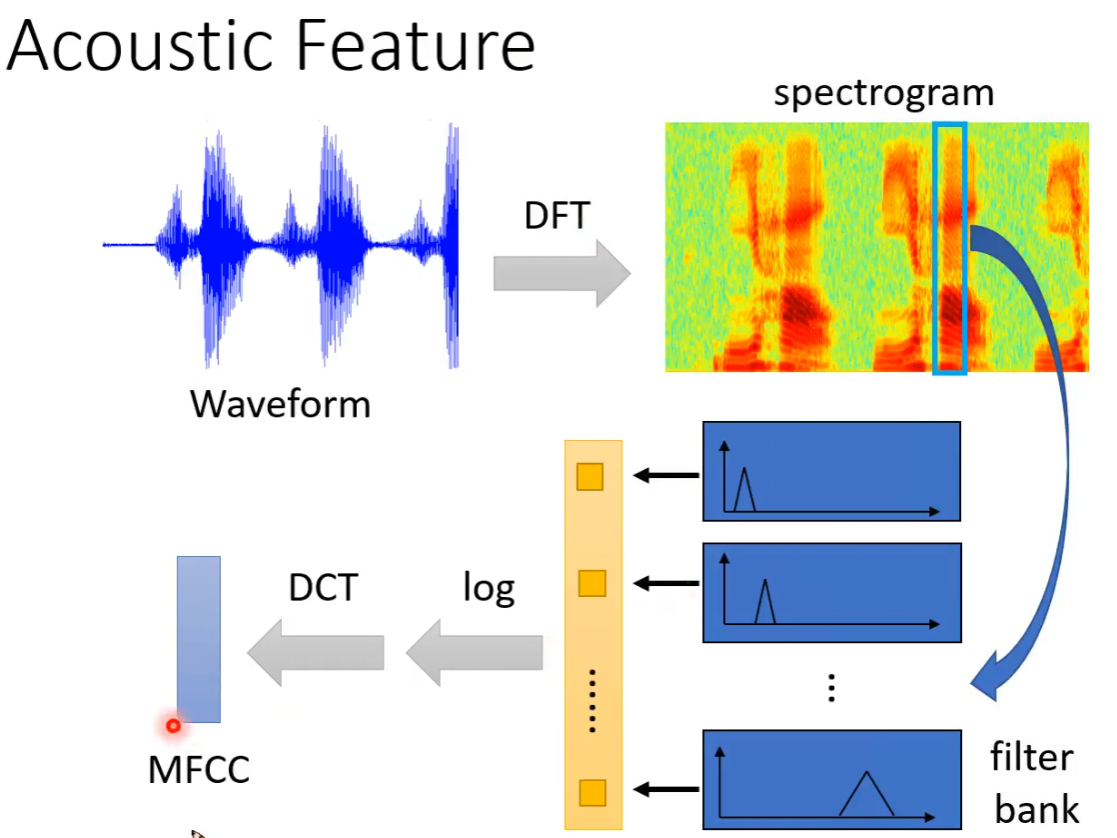
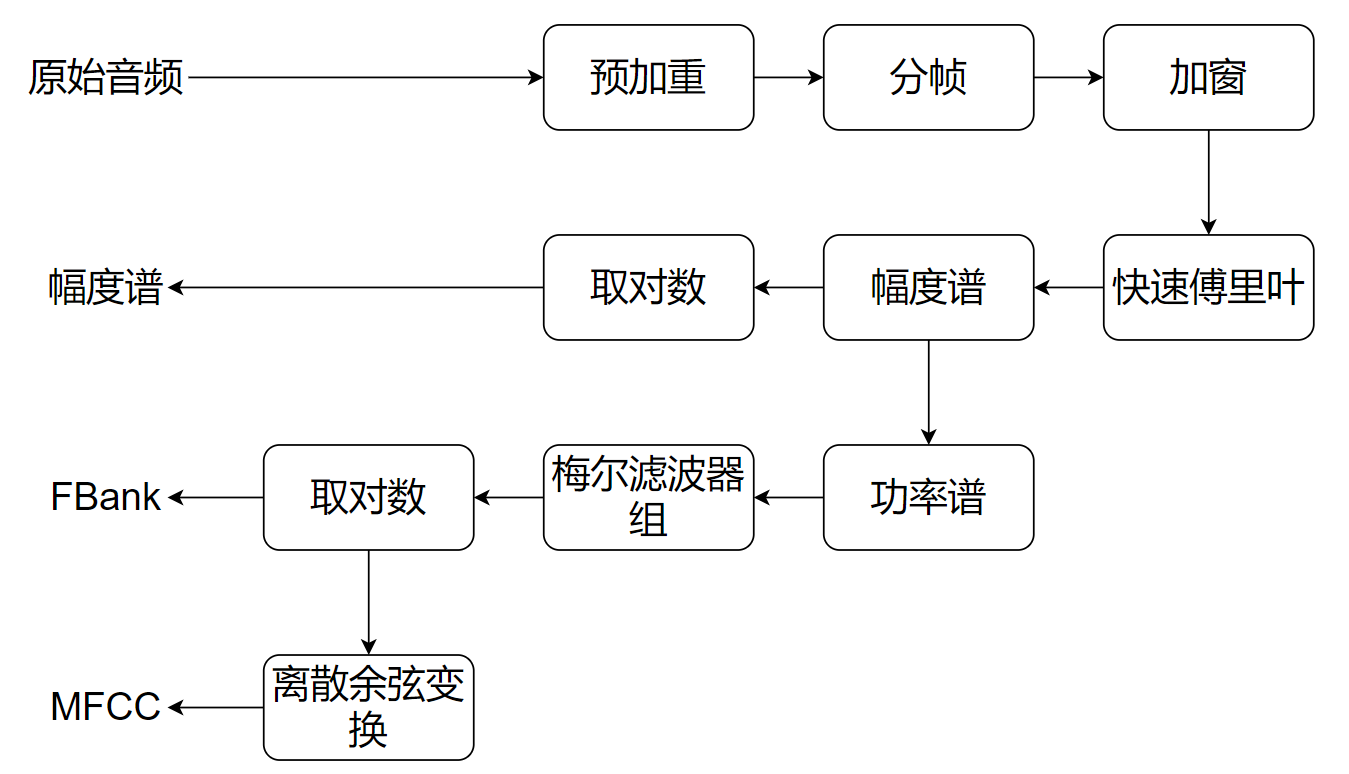 


### 课程二（30%）

自行构建幅度谱

##### 1.librosa加载音频

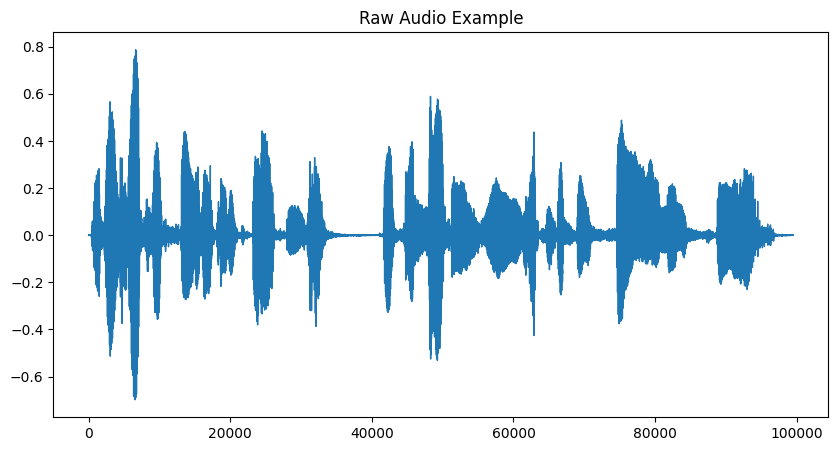

In [33]:
audio_file = 'LJ001-0011.wav'
ipd.Audio(audio_file)
data, sr = librosa.load(audio_file)
pd.Series(data).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

##### 2.实现预加重函数
预加重处理相当于将语音信号通过一个高通滤波器，用来提升高频部分，因为语音信号的高频能量通常较低，预加重可以平衡频谱，便于后续分析。

y[t]=x[t]−α⋅x[t−1]

α通常取0.97

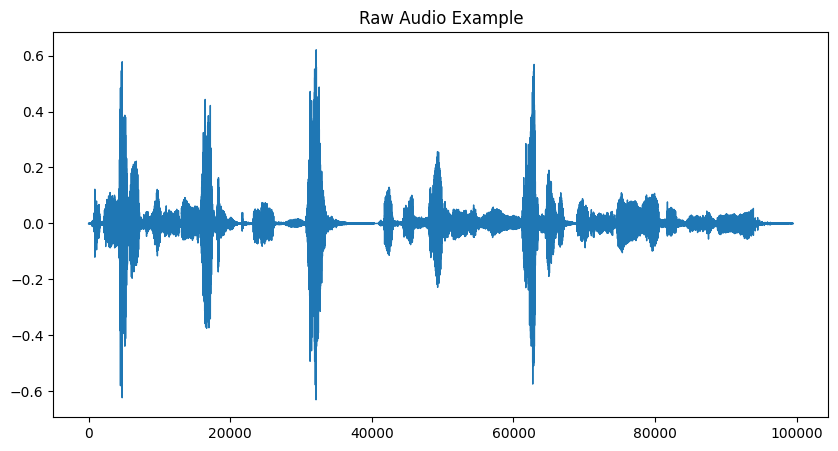

In [34]:
def pre_emphasis(sig, alpha=0.97):
    """
    function:预加重
    para: sig:要进行处理的音频数据
    return 进行加强处理后的音频数据
    """
    # TODO：实现预加重函数
    # 高通滤波: y[t] = x[t] - alpha * x[t-1], alpha 通常取 0.97
    return np.append(sig[0], sig[1:] - alpha * sig[:-1])
step1 = pre_emphasis(data)
pd.Series(step1).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

#观察对比预加重处理前后的音频图像，图像的哪些特征反应了预加重处理的效果？

##### 3.实现分帧函数

通常帧长25ms,帧位移10ms,为了确保所有帧采样数相等,需要对信号最后进行填充

查看分帧后的shape,分帧后shape变成二维

In [35]:
def framing(sig,fs,frame_len_s=0.025,frame_shift_s=0.01):
    """
    function：分帧
    para：
        frame_len_s:每一帧的长度,单位为s
        frame_shift_s:分帧的shift,单位为s
        fs：采样率，hz
        sig：要进行分帧的音频信号
    return：进行分帧后的数据，一个二维数组，一行是一帧信号
    """
    # TODO：实现分帧函数
    sig_len = len(sig)
    frame_len = int(round(frame_len_s * fs))       # 每帧采样点数
    frame_shift = int(round(frame_shift_s * fs))   # 帧移采样点数
    # 帧数(向上取整保证覆盖整段信号)
    num_frame = int(np.ceil((sig_len - frame_len) / frame_shift)) + 1
    # 末尾补零, 使每帧采样数相等
    pad_len = (num_frame - 1) * frame_shift + frame_len
    pad_sig = np.append(sig, np.zeros(pad_len - sig_len))
    # 构造每帧索引并取值 -> [num_frame, frame_len]
    indices = np.arange(frame_len)[None, :] + np.arange(num_frame)[:, None] * frame_shift
    frames = pad_sig[indices.astype(np.int64)]
    return frames

step2 = framing(step1,sr)
print(step2.shape)

(451, 551)


##### 4.实现加窗函数

hamming窗提示:numpy.hamming()

加窗方式:frame_sig_window(n)=frame_sig(n)⋅window(n)

In [36]:
#Xw(n)=X(n)⋅w(n)
def add_window(frame_sig,fs,frame_len_s=0.025):
    """
    function：加窗
    para：
        frame_len_s：每一帧的长度,单位为s
        fs：采样率
        frame_sig:进行分帧后的数据
    return：加窗后的数据
    """
    # TODO：实现加窗函数（使用hamming窗）
    frame_len = frame_sig.shape[1]
    window = np.hamming(frame_len)   # 汉明窗
    return frame_sig * window

step3 = add_window(step2,sr)
step3.shape

# TODO：实际上加窗不止有汉明窗，还有其他窗函数，问问大模型，还有哪些窗函数？让他帮你实现其中一个，最后看看不同窗函数的幅度谱图有什么区别。

(451, 551)

##### 5.实现短时傅里叶变换函数得到幅度谱

nfft通常为256或512

STFT提示:numpy.fft.rfft()

幅度谱需要取模

In [37]:
def stft(frame_sig, nfft=512):
    """
    function：短时傅里叶变换将帧信号变为帧功率（对应幅值频发）
    para：
        frame_sig: 分帧后的信号
        nfft: fft点数
    return: 返回分帧信号的幅度谱和功率谱
    """
    # TODO：得到幅度谱
    frame_spec = np.fft.rfft(frame_sig, nfft)   # 实数 FFT
    frame_mag = np.abs(frame_spec)              # 取模得幅度谱 [num_frame, nfft/2+1]

    # 功率谱
    frame_pow = (frame_mag ** 2) * 1.0 / nfft # 取平方
    return frame_mag,frame_pow

frame_mag, step4 = stft(step3)
frame_mag.shape

(451, 257)

##### 6.取对数得到可绘制查看的幅度谱,并绘制

$F_{\text{dB}} = 20 \times \log_{10} (F)$

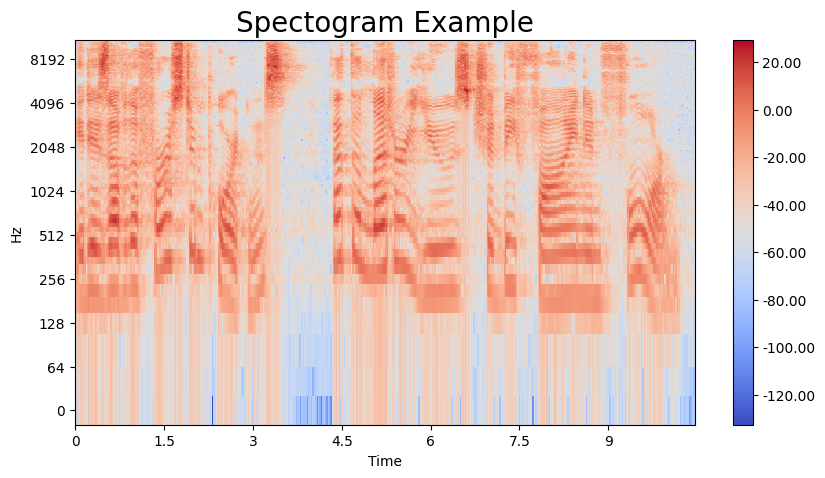

In [38]:
frame_log = 20 * np.log10(frame_mag)
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(frame_log.T,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

##### 7. 加窗思考题：不同窗函数的幅度谱对比

课程二加窗单元的思考题要求：除汉明窗外还有哪些窗函数？实现其中一个，并对比不同窗的幅度谱差异。下面用同一帧信号 `step2` 分别加 **矩形 / 汉明 / 汉宁 / 布莱克曼** 窗，观察其幅度谱区别（结论见文末「记录题目与思考」）。

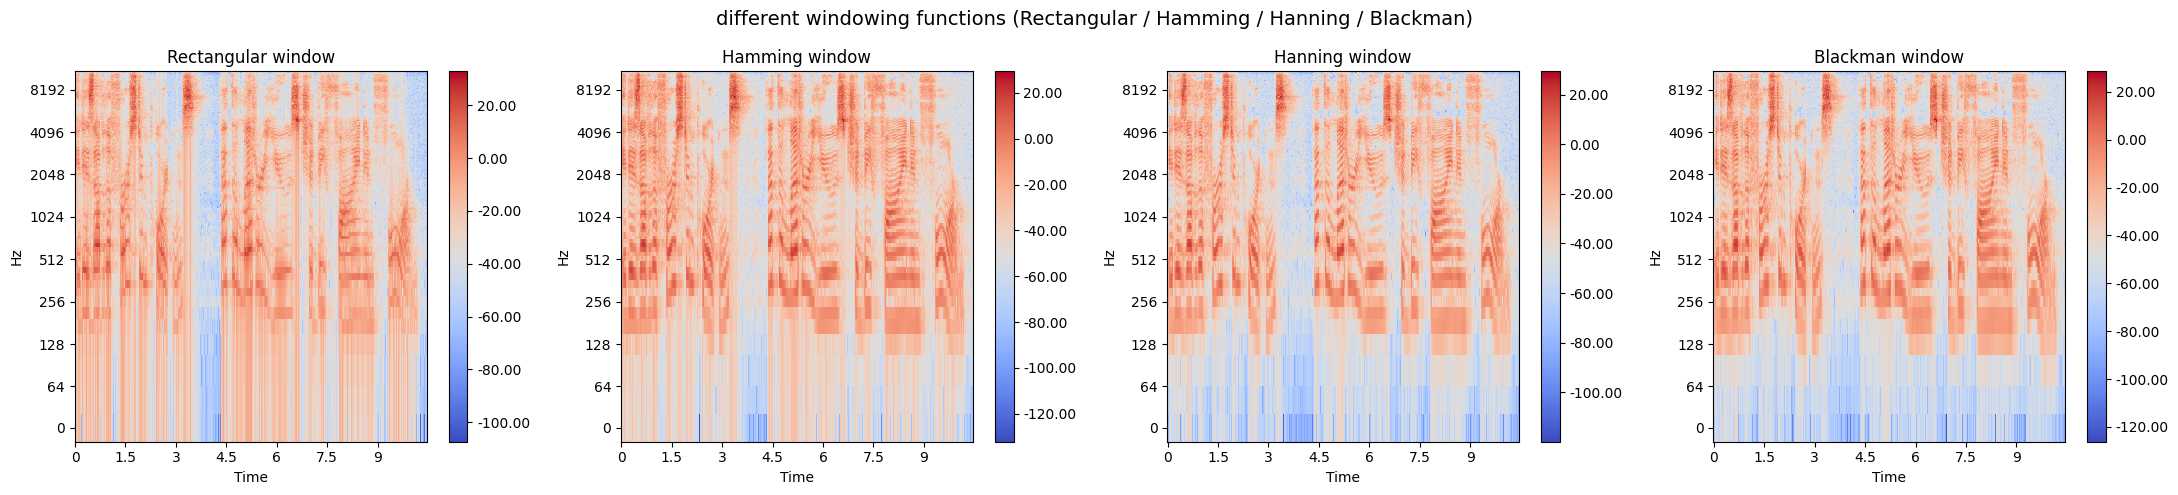

In [46]:
# 加窗思考题：对比不同窗函数(矩形/汉明/汉宁/布莱克曼)的幅度谱差异
# 复用课程二已实现的分帧结果 step2 与短时傅里叶变换 stft
window_funcs = {
    'Rectangular': np.ones,      # 矩形窗(等价于不加窗)
    'Hamming':     np.hamming,   # 汉明窗(本实验默认)
    'Hanning':     np.hanning,   # 汉宁(Hann)窗
    'Blackman':    np.blackman,  # 布莱克曼窗
}

frame_len = step2.shape[1]
fig, axes = plt.subplots(1, len(window_funcs), figsize=(22, 5))
for ax, (name, wf) in zip(axes, window_funcs.items()):
    frames_win = step2 * wf(frame_len)      # 对每帧加对应的窗
    mag, _ = stft(frames_win)               # 复用课程二实现的 STFT 得到幅度谱
    log_mag = 20 * np.log10(mag + 1e-8)     # 转 dB
    img = librosa.display.specshow(log_mag.T, x_axis='time', y_axis='log', ax=ax)
    ax.set_title(f'{name} window')
    fig.colorbar(img, ax=ax, format='%0.2f')
fig.suptitle('different windowing functions (Rectangular / Hamming / Hanning / Blackman)', fontsize=14)
plt.tight_layout()
plt.show()

# 观察：矩形窗旁瓣最高、频谱泄漏最严重(谐波之间底噪大)；汉明/汉宁次之；
# 布莱克曼窗旁瓣最低、谱最"干净"，但主瓣最宽、频率分辨率略降。汉明窗是分辨率与泄漏的常用折中。

### 课程三 （45%）

实现FBank和MFCC

##### 1.实现mel滤波
人耳对低频更敏感,但对高频变化的分辨率较低,所以要使用Mel频率刻度来更符合人耳的听觉特性.

奈奎斯特采样定理:当采样频率fs.max大于信号中最高频率fmax的2倍时(fs.max>2fmax)，采样之后的数字信号完整地保留了原始信号中的信息。

$n_{\text{filter}}$取40, nfft取512

$M_{\text{min}} = 0$

$M_{\text{max}} = 2595 \log_{10} \left( 1 + \frac{fs}{2 \times 700} \right)$

$M_i = \text{linspace}(M_{\text{min}}, M_{\text{max}}, n_{\text{filter}} + 2)$

$f_i = 700 \left(10^{M_i / 2595} - 1 \right)$

$H_m(k) =
\begin{cases}
  0, & k < f(m-1) \text{ or } k > f(m+1) \\
  \frac{k - f(m-1)}{f(m) - f(m-1)}, & f(m-1) \leq k \leq f(m) \\
  \frac{f(m+1) - k}{f(m+1) - f(m)}, & f(m) < k \leq f(m+1)
\end{cases}$

$\text{filter\_banks} = P \cdot H_m^T$

查看最后维度

In [40]:
def mel_filter(frame_pow, fs, n_filter=40, nfft=512):
    """
    function:mel 滤波器系数计算
    para:
        frame_pow: 分帧信号功率谱
        fs: 采样率 hz
        n_filter: 滤波器个数
        nfft: fft点数
    return: 分帧信号功率谱mel滤波后的值的对数值
    mel = 2595 * log10(1 + f/700) # 频率到mel值映射
    f = 700 * (10^(m/2595) - 1 # mel值到频率映射
    上述过程本质上是对频率f对数化
    """

    mel_min = 0 # 最低mel值
    mel_max = 2595 * np.log10(1 + (fs / 2) / 700) # 最高mel值，最大信号频率为 fs/2
    mel_points = np.linspace(mel_min, mel_max, n_filter + 2)  # TODO: n_filter个mel值均匀分布与最低与最高mel值之间
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)  # TODO: mel值对应回频率点，频率间隔指数化
    filter_edge = np.floor(hz_points * (nfft + 1) / fs) # 对应到fft的点数比例上

    fbank = np.zeros((n_filter, int(nfft / 2 + 1)))
    # TODO:求mel滤波器系数
    for m in range(1, n_filter + 1):
        f_left = int(filter_edge[m - 1])    # 左边界
        f_center = int(filter_edge[m])      # 中心
        f_right = int(filter_edge[m + 1])   # 右边界
        for k in range(f_left, f_center):
            fbank[m - 1, k] = (k - f_left) / (f_center - f_left)
        for k in range(f_center, f_right):
            fbank[m - 1, k] = (f_right - k) / (f_right - f_center)

    # TODO:mel 滤波
    # 提示：[num_frame, nfft/2 + 1] * [nfft/2 + 1, n_filter] = [num_frame, n_filter]
    filter_banks = np.dot(frame_pow, fbank.T)

    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    # np.finfo函数是根据括号中的类型来获得信息，获得符合这个类型的数型, eps是取非负的最小值
    return filter_banks
step5 = mel_filter(step4, sr)
print(step5.shape)

(451, 40)


##### 3.取对数得到可绘制查看的梅尔谱,并绘制,注意矩阵维度,可能需要转置

$P_{\text{dB}} = 20 \times \log_{10} (P)$

In [41]:
fbank = 20 * np.log10(step5)
fbankT = fbank.T   # 方便可视化
print(fbankT.shape)

(40, 451)


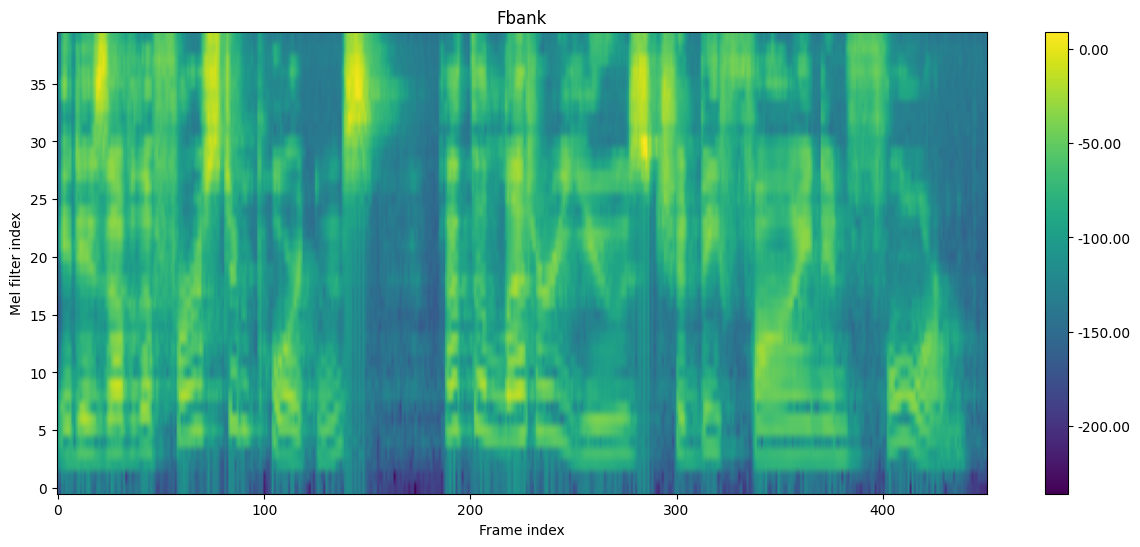

In [42]:
plt.figure(figsize=(15, 6))
plt.imshow(fbankT, origin='lower', aspect='auto')
plt.colorbar(format='%0.2f')
plt.title("Fbank")
plt.xlabel("Frame index")
plt.ylabel("Mel filter index")
plt.show()

##### 4.使用fbank经过离散余弦变换函数得到mfcc,并绘图

In [43]:
from scipy.fftpack import dct
def discrete_cosine_transform(filter_banks):
    """
    function：离散余弦变换
    para：filter_banks:fbanks
    return: mfcc
    """
    num_ceps = 12
    # TODO: 离散余弦变换
    # 对每一帧(沿滤波器维度)做 DCT-II, 取 1..num_ceps 维(丢弃第0维直流分量)
    mfcc = dct(filter_banks, type=2, axis=1, norm="ortho")[:, 1:(num_ceps + 1)]
    """
    scipy.fftpack.dct:返回任意类型序列x的离散余弦变换。
    """
    return mfcc
mfcc  = discrete_cosine_transform(fbank)
mfcc.shape

(451, 12)

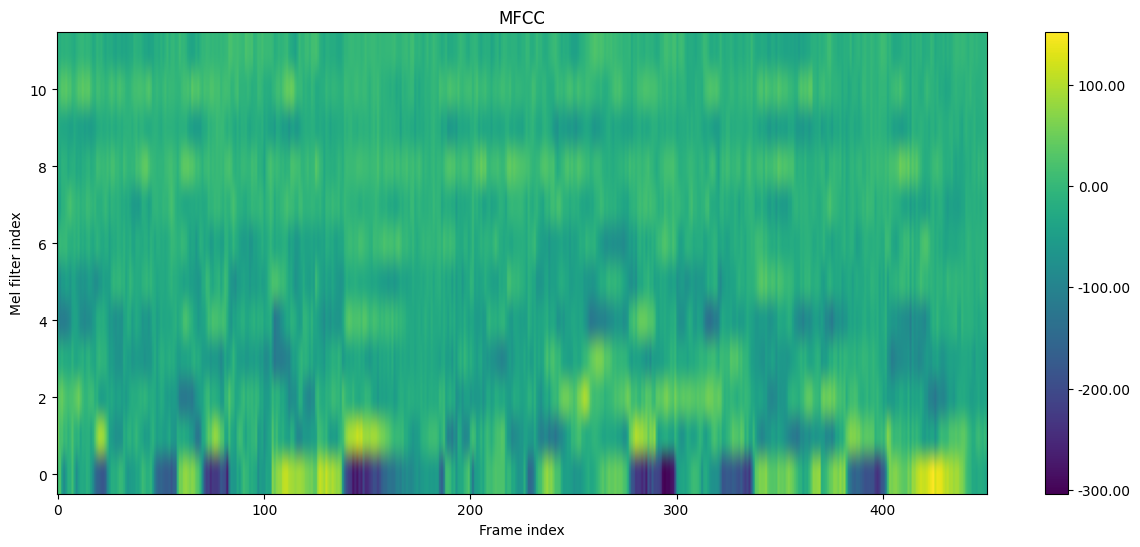

In [44]:
plt.figure(figsize=(15, 6))
plt.imshow(mfcc.T, origin='lower', aspect='auto')
plt.colorbar(format='%0.2f')
plt.title("MFCC")
plt.xlabel("Frame index")
plt.ylabel("Mel filter index")
plt.show()

### 课程四（加分项：10%）
           

基于预训练模型的深度音频特征提取

在前面的实验中，你已经学会了如何手动提取传统的音频特征（MFCC、FBank）。近年来，基于深度学习的预训练模型（如 **Wav2Vec2、HuBERT、Whisper**）可以从音频中自动学习到更强大的特征表示，广泛应用于语音识别、说话人识别等任务。本实验需要你加载一个预训练的 **Wav2Vec2** 或**HuBERT**模型（二选一），用它来提取示例音频LJ001-0011.wav的深度特征。

Wav2Vec2模型：

torchaudio文档：https://docs.pytorch.org/audio/stable/generated/torchaudio.models.Wav2Vec2Model.html

Hugging Face Transformers文档：https://huggingface.co/docs/transformers/model_doc/wav2vec2

HuBERT模型：

github仓库：https://github.com/facebookresearch/fairseq/tree/main/examples/hubert

Hugging Face Transformers文档：https://huggingface.co/docs/transformers/model_doc/hubert

模型要求采样率: 16000
Transformer 层数: 12
最后一层特征 shape [batch, frames, dim]: (1, 225, 768)


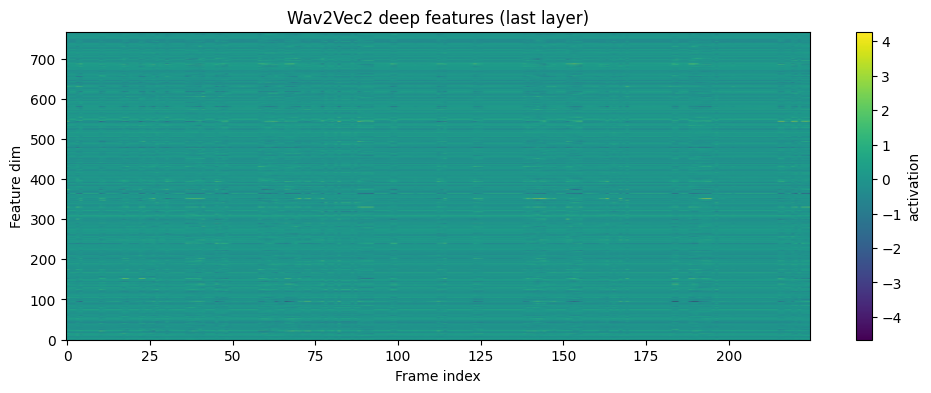

In [45]:
#TODO：深度音频特征提取
# 使用 torchaudio 自带的预训练 Wav2Vec2 (BASE) 模型
import torch
import torchaudio

bundle = torchaudio.pipelines.WAV2VEC2_BASE   # 预训练 wav2vec2 base
model = bundle.get_model().eval()
print("模型要求采样率:", bundle.sample_rate)

wav, sr_in = torchaudio.load("LJ001-0011.wav")
# 若采样率不符, 重采样到模型要求的采样率
if sr_in != bundle.sample_rate:
    wav = torchaudio.functional.resample(wav, sr_in, bundle.sample_rate)
# 转单声道
if wav.shape[0] > 1:
    wav = wav.mean(dim=0, keepdim=True)

with torch.inference_mode():
    features, _ = model.extract_features(wav)   # 每个 transformer 层的隐藏特征

print("Transformer 层数:", len(features))
print("最后一层特征 shape [batch, frames, dim]:", tuple(features[-1].shape))

# 可视化最后一层深度特征
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.imshow(features[-1][0].numpy().T, aspect="auto", origin="lower")
plt.colorbar(label="activation")
plt.xlabel("Frame index")
plt.ylabel("Feature dim")
plt.title("Wav2Vec2 deep features (last layer)")
plt.show()

## 记录题目与思考

### 思考题一：预加重前后对比（课程二 · 预加重）
> 观察对比预加重处理前后的音频图像，图像的哪些特征反映了预加重处理的效果？

预加重是一阶高通滤波 $y[t]=x[t]-0.97\,x[t-1]$。对比预加重前后：
- **时域波形**：整体幅度（尤其由低频包络贡献的大摆幅）被压低，波形显得更瘦、快速抖动更明显。因为相邻采样相减削弱了缓慢变化的低频分量、放大了快速变化的高频分量。
- **幅度谱**：低频能量下降、高频相对抬升，整体频谱更平坦。

这正体现了预加重"提升高频、平衡频谱"的作用：补偿语音高频能量随频率约 $-6$ dB/oct 的自然衰减，有利于后续分帧、加窗与倒谱分析。

### 思考题二：其它窗函数及幅度谱对比（课程二 · 加窗）
> 除汉明窗外还有哪些窗函数？实现其中一个，并对比不同窗的幅度谱差异。

常见窗函数还有 **矩形窗、汉宁(Hann)窗、布莱克曼(Blackman)窗、三角窗、凯泽(Kaiser)窗** 等，区别在于主瓣宽度 与旁瓣衰减的折中：矩形窗主瓣最窄但旁瓣最高（约 $-13$ dB）、频谱泄漏最严重；汉明窗旁瓣约 $-43$ dB；汉宁窗旁瓣约 $-31$ dB 但滚降快；布莱克曼窗旁瓣最低（约 $-58$ dB）但主瓣最宽、频率分辨率下降。

上一单元的对比图（矩形/汉明/汉宁/布莱克曼）可见：**布莱克曼窗**的幅度谱最"干净"（谐波间底噪最低、旁瓣泄漏最小）但谱峰略变宽；**矩形窗**泄漏最明显、底噪最大。因此实际语音特征提取中常用**汉明窗**作为分辨率与泄漏之间的折中，这也是本实验默认选它的原因。

### 加分实验思考：基于预训练模型的深度音频特征（课程四）
用 torchaudio 预训练 **Wav2Vec2 (BASE)** 提取 `LJ001-0011.wav` 的深度特征时，需先把音频**重采样到模型要求的 16 kHz** 并转单声道。模型输出 12 层 Transformer 隐藏表示，最后一层形状为 `[1, 帧数, 768]`。

与手工的 **MFCC / FBank** 相比：Wav2Vec2 特征维度更高（768 vs 12/40），由大规模自监督预训练学到，编码了更丰富的上下文与音素/语义信息，在 ASR、说话人识别等下游任务上通常显著强于传统特征；代价是依赖预训练大模型、可解释性较弱。这让我直观体会到语音特征从手工信号处理到数据驱动表示学习的演进。